# 1. Estrategia de Datos y Calibración (España 2024)

En este notebook definimos los parámetros empíricos que alimentarán nuestro modelo ABM. La clave de un buen modelo basado en agentes es que la **heterogeneidad** de los agentes no sea aleatoria, sino que siga distribuciones estadísticas observadas en la realidad.

## 2. Definición de Variables con Datos Reales

### A. El Mercado Laboral (Salarios y Productividad)
* **Salario Real ($w$):** Según el INE (2024), el salario medio en España ronda los **17.5 €/h netos**. No usaremos una media fija, sino una **Distribución Log-Normal**, que refleja mejor la desigualdad salarial (mucha gente con salarios bajos y pocos con salarios muy altos).
* **Productividad ($z$):** El PIB por hora trabajada en España es de aproximadamente **68 €/h**. Usaremos una **Distribución Normal** para simular empresas con distintos niveles de eficiencia.

### B. El Sector Doméstico (Hipótesis de Anisi)
* **Productividad Extramercado ($z_b$):** Dado que el trabajo en el hogar no goza de economías de escala, fijamos una media de **10.5 €/h** (basado en el coste de servicios domésticos y cuidados).
* **Deseo de Consumo ($c$):** Calibrado en **7.0 €/h** para equilibrar el modelo según los resultados de la calibración estadística final.

## Instalar librería seaborn

In [32]:
import sys
!{sys.executable} -m pip install seaborn

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la población para la visualización
N = 1000
np.random.seed(42)

# 1. GENERACIÓN DE SALARIOS (Log-Normal)
# Para una media de ~17.5 y una distribución realista
mu_w, sigma_w = 2.8, 0.25
salarios = np.random.lognormal(mu_w, sigma_w, N)

# 2. GENERACIÓN DE PRODUCTIVIDAD (Normal)
# Media de 68 (PIB/h España)
productividad = np.random.normal(68, 8, N)

# 3. GENERACIÓN DE PRODUCTIVIDAD DOMÉSTICA (Normal)
prod_domestica = np.random.normal(10.5, 2, N)

# 4. GENERACIÓN DE DESEO DE CONSUMO (Uniforme)
consumo_deseado = np.random.uniform(5, 9, N)

## Visualización de la Calibración

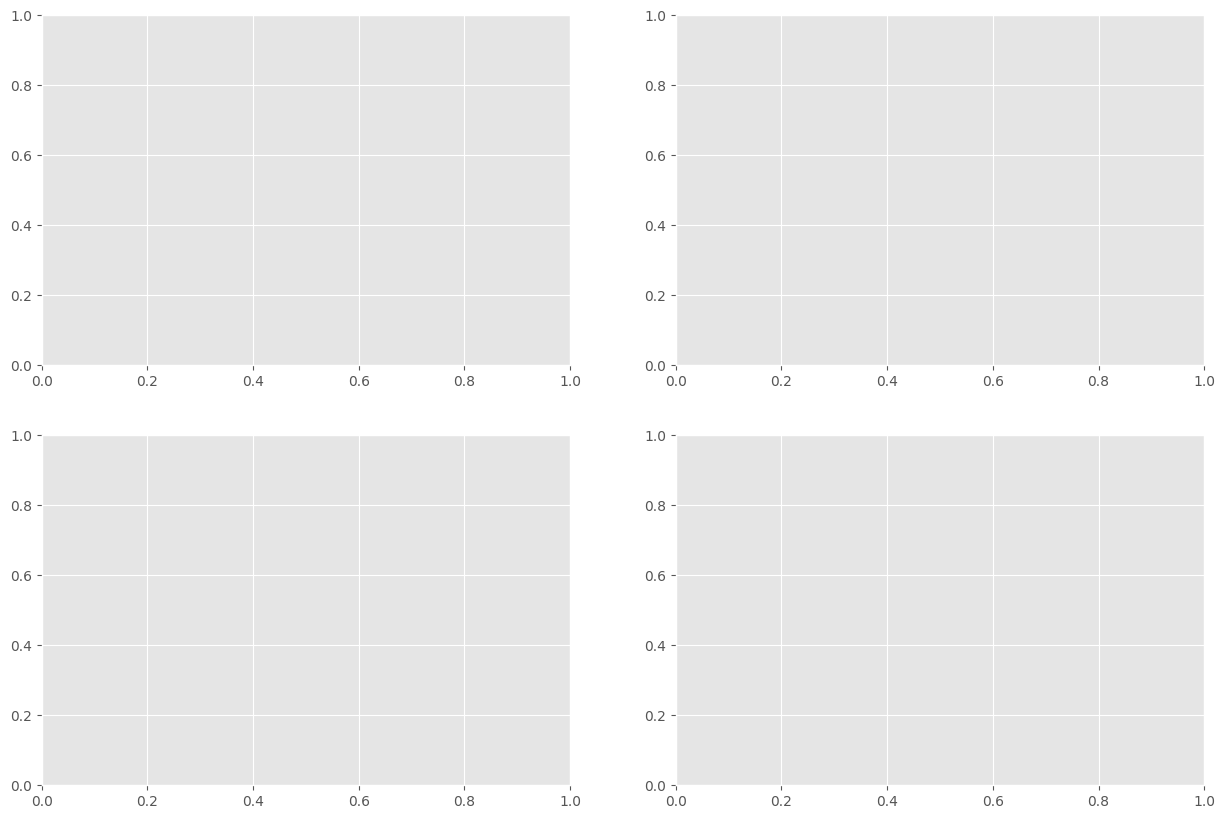

In [34]:
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

## Histograma de Salarios

In [35]:
sns.histplot(salarios, kde=True, color='royalblue', ax=axes[0,0])
axes[0,0].set_title("Distribución Log-Normal de Salarios (w)", fontweight='bold')
axes[0,0].set_xlabel("Euros / Hora")
axes[0,0].axvline(np.mean(salarios), color='red', linestyle='--', label=f'Media: {np.mean(salarios):.2f}')
axes[0,0].legend()

## Histograma Productividad

In [36]:
sns.histplot(productividad, kde=True, color='seagreen', ax=axes[0,1])
axes[0,1].set_title("Distribución de Productividad del Mercado (z)", fontweight='bold')
axes[0,1].set_xlabel("PIB / Hora")
axes[0,1].axvline(68, color='red', linestyle='--', label='Objetivo: 68€/h')
axes[0,1].legend()

## Histograma Consumo

In [37]:
sns.histplot(consumo_deseado, kde=True, color='orange', ax=axes[1,0])
axes[1,0].set_title("Heterogeneidad en el Deseo de Consumo (c)", fontweight='bold')
axes[1,0].set_xlabel("Euros / Hora")

Text(0.5, 4.4444444444444375, 'Euros / Hora')

## Histograma Prod. Doméstica

In [38]:
sns.histplot(prod_domestica, kde=True, color='purple', ax=axes[1,1])
axes[1,1].set_title("Productividad Extramercado (zb)", fontweight='bold')
axes[1,1].set_xlabel("Euros / Hora")

Text(0.5, 4.4444444444444375, 'Euros / Hora')

## Guardamos el gráfico obtenido en la carpeta data

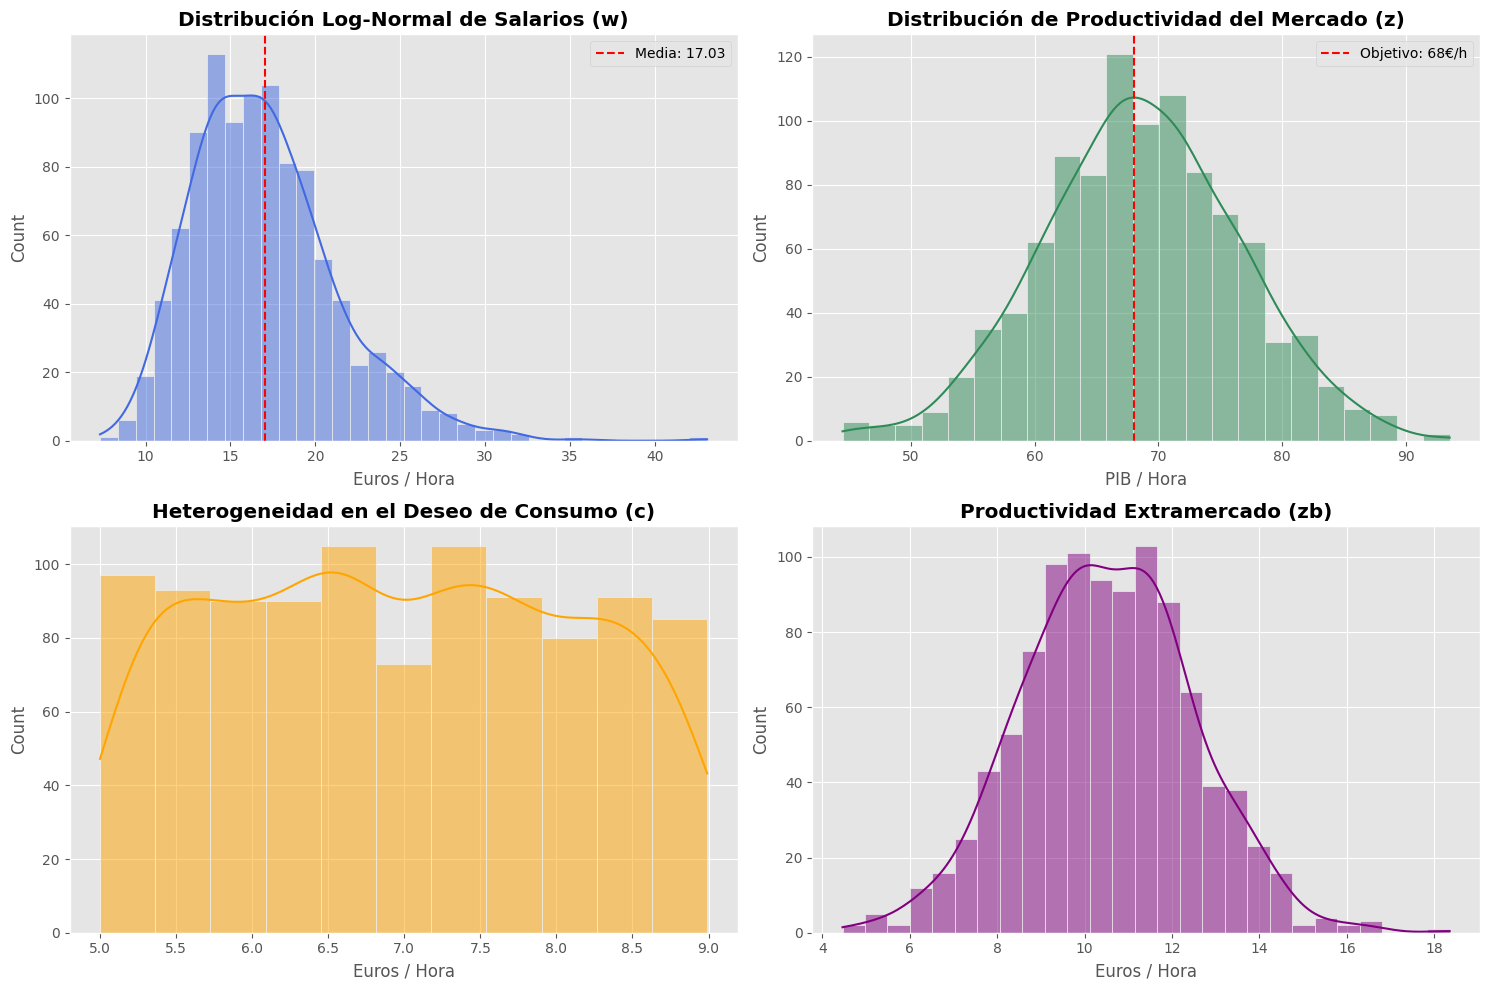

In [39]:
# VISUALIZACIÓN DE LA CALIBRACIÓN
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histograma Salarios
sns.histplot(salarios, kde=True, color='royalblue', ax=axes[0,0])
axes[0,0].set_title("Distribución Log-Normal de Salarios (w)", fontweight='bold')
axes[0,0].set_xlabel("Euros / Hora")
axes[0,0].axvline(np.mean(salarios), color='red', linestyle='--', label=f'Media: {np.mean(salarios):.2f}')
axes[0,0].legend()

# Histograma Productividad
sns.histplot(productividad, kde=True, color='seagreen', ax=axes[0,1])
axes[0,1].set_title("Distribución de Productividad del Mercado (z)", fontweight='bold')
axes[0,1].set_xlabel("PIB / Hora")
axes[0,1].axvline(68, color='red', linestyle='--', label='Objetivo: 68€/h')
axes[0,1].legend()

# Histograma Consumo
sns.histplot(consumo_deseado, kde=True, color='orange', ax=axes[1,0])
axes[1,0].set_title("Heterogeneidad en el Deseo de Consumo (c)", fontweight='bold')
axes[1,0].set_xlabel("Euros / Hora")

# Histograma Prod. Doméstica
sns.histplot(prod_domestica, kde=True, color='purple', ax=axes[1,1])
axes[1,1].set_title("Productividad Extramercado (zb)", fontweight='bold')
axes[1,1].set_xlabel("Euros / Hora")

plt.tight_layout()
plt.savefig('../data/visualizacion_datos_calibrados.png')
plt.show()

# 3. Conclusión de la Estrategia

Este análisis previo asegura que el modelo ABM no parte de valores arbitrarios. Los resultados de la simulación serán válidos porque:
1. **Respetan la desigualdad:** El uso de log-normal para salarios es fundamental para capturar el dualismo de Anisi.
2. **Están anclados a 2024:** Los valores medios coinciden con la EPA y el INE.
3. **Permiten la frustración:** Al definir un consumo heterogéneo, algunos agentes entrarán en frustración ($I_3 > 1$) mientras otros no, lo que enriquece el análisis macroeconómico.